# Thesis results replica

This is the executable companion to `docs/report-clean/main.tex`,
reproducing every figure and table in its Results section **1:1**.
It uses the historical reference CSVs in `results/` and the exact figure
assets included by the report. Run all cells from top to bottom.

## Figure 1 — YOLOv8 comparison grid

Qualitative comparison between YOLOv8n and YOLOv8x on COCO validation images.


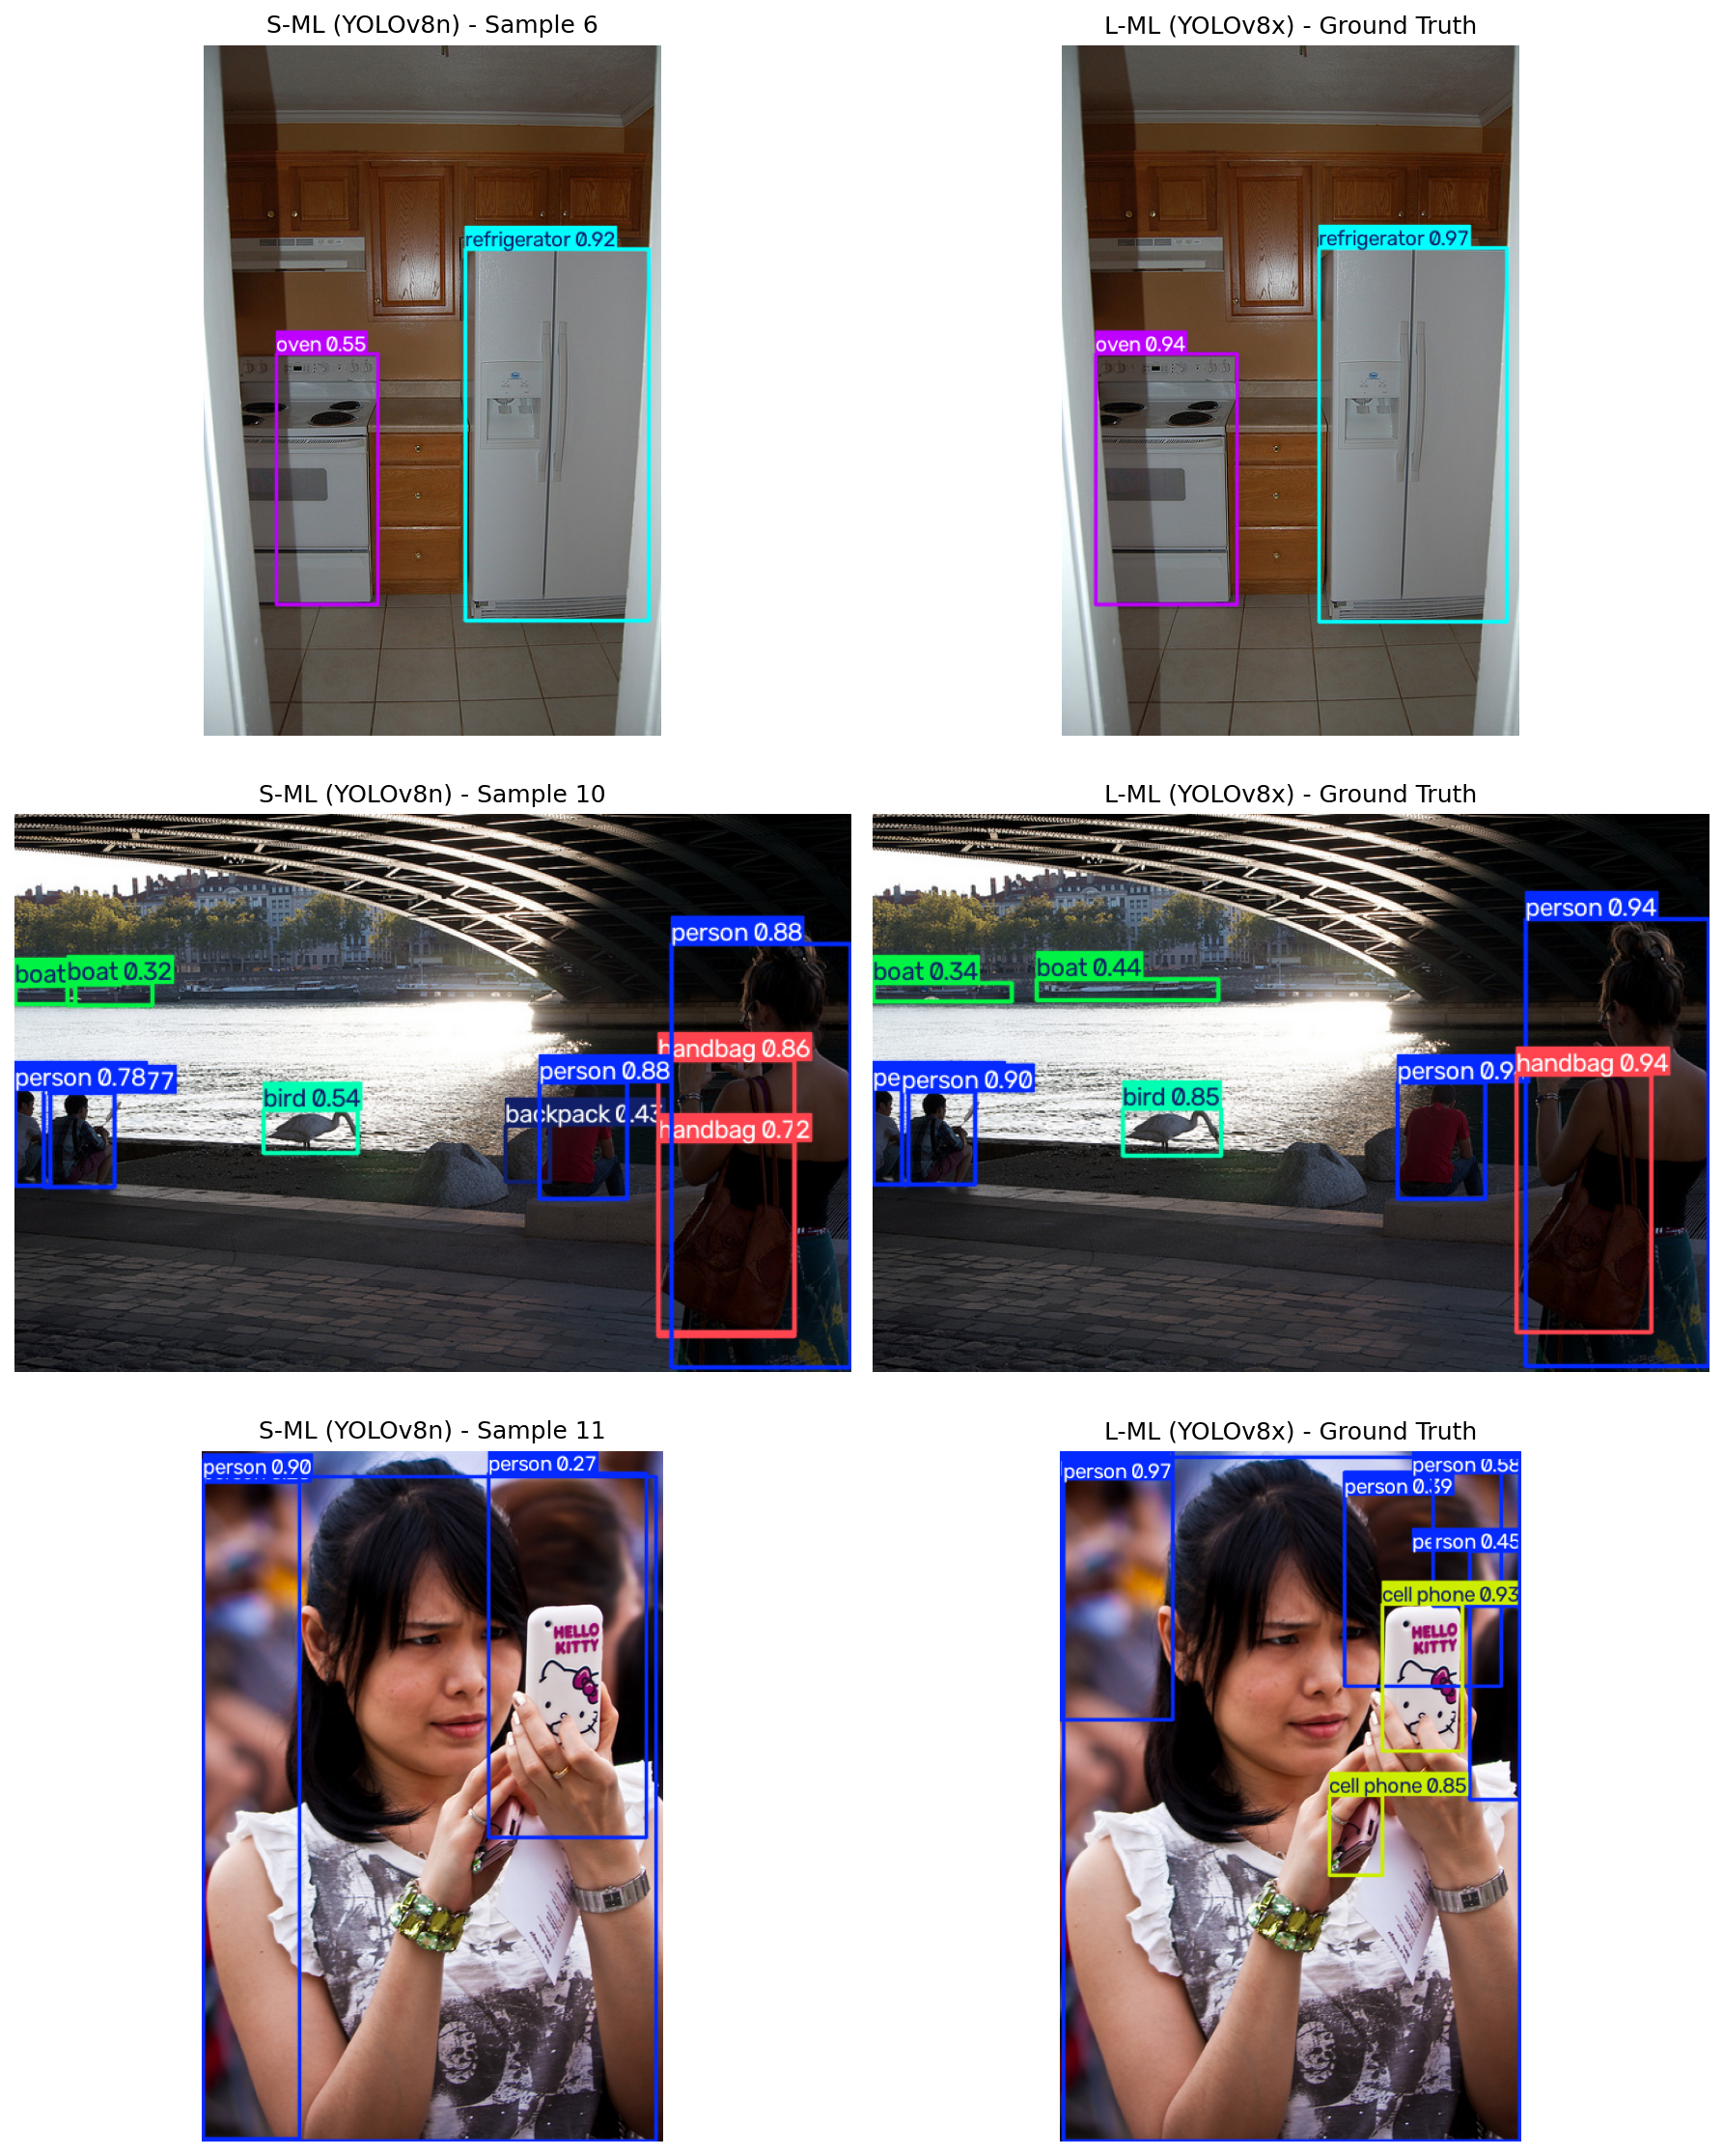

In [150]:
import matplotlib.pyplot as plt
import os
from PIL import Image
from visualization_scripts.generate_comparison_grid import generate_grid
from IPython.display import Image as IPImage, display

# if yolov8_comparison_grid.png does not exist, run generate_yolov8_comparison_grid.py to create it
if not os.path.exists("figures/yolov8_comparison_grid.png"):
    %run visualization_scripts/generate_yolov8_comparison_grid.py

display(IPImage(filename="figures/yolov8_comparison_grid.png"))


## Figure 2 — Raw predictions versus NMS

Visualization of the S-ML raw predictions (yellow) versus final NMS detections (purple).


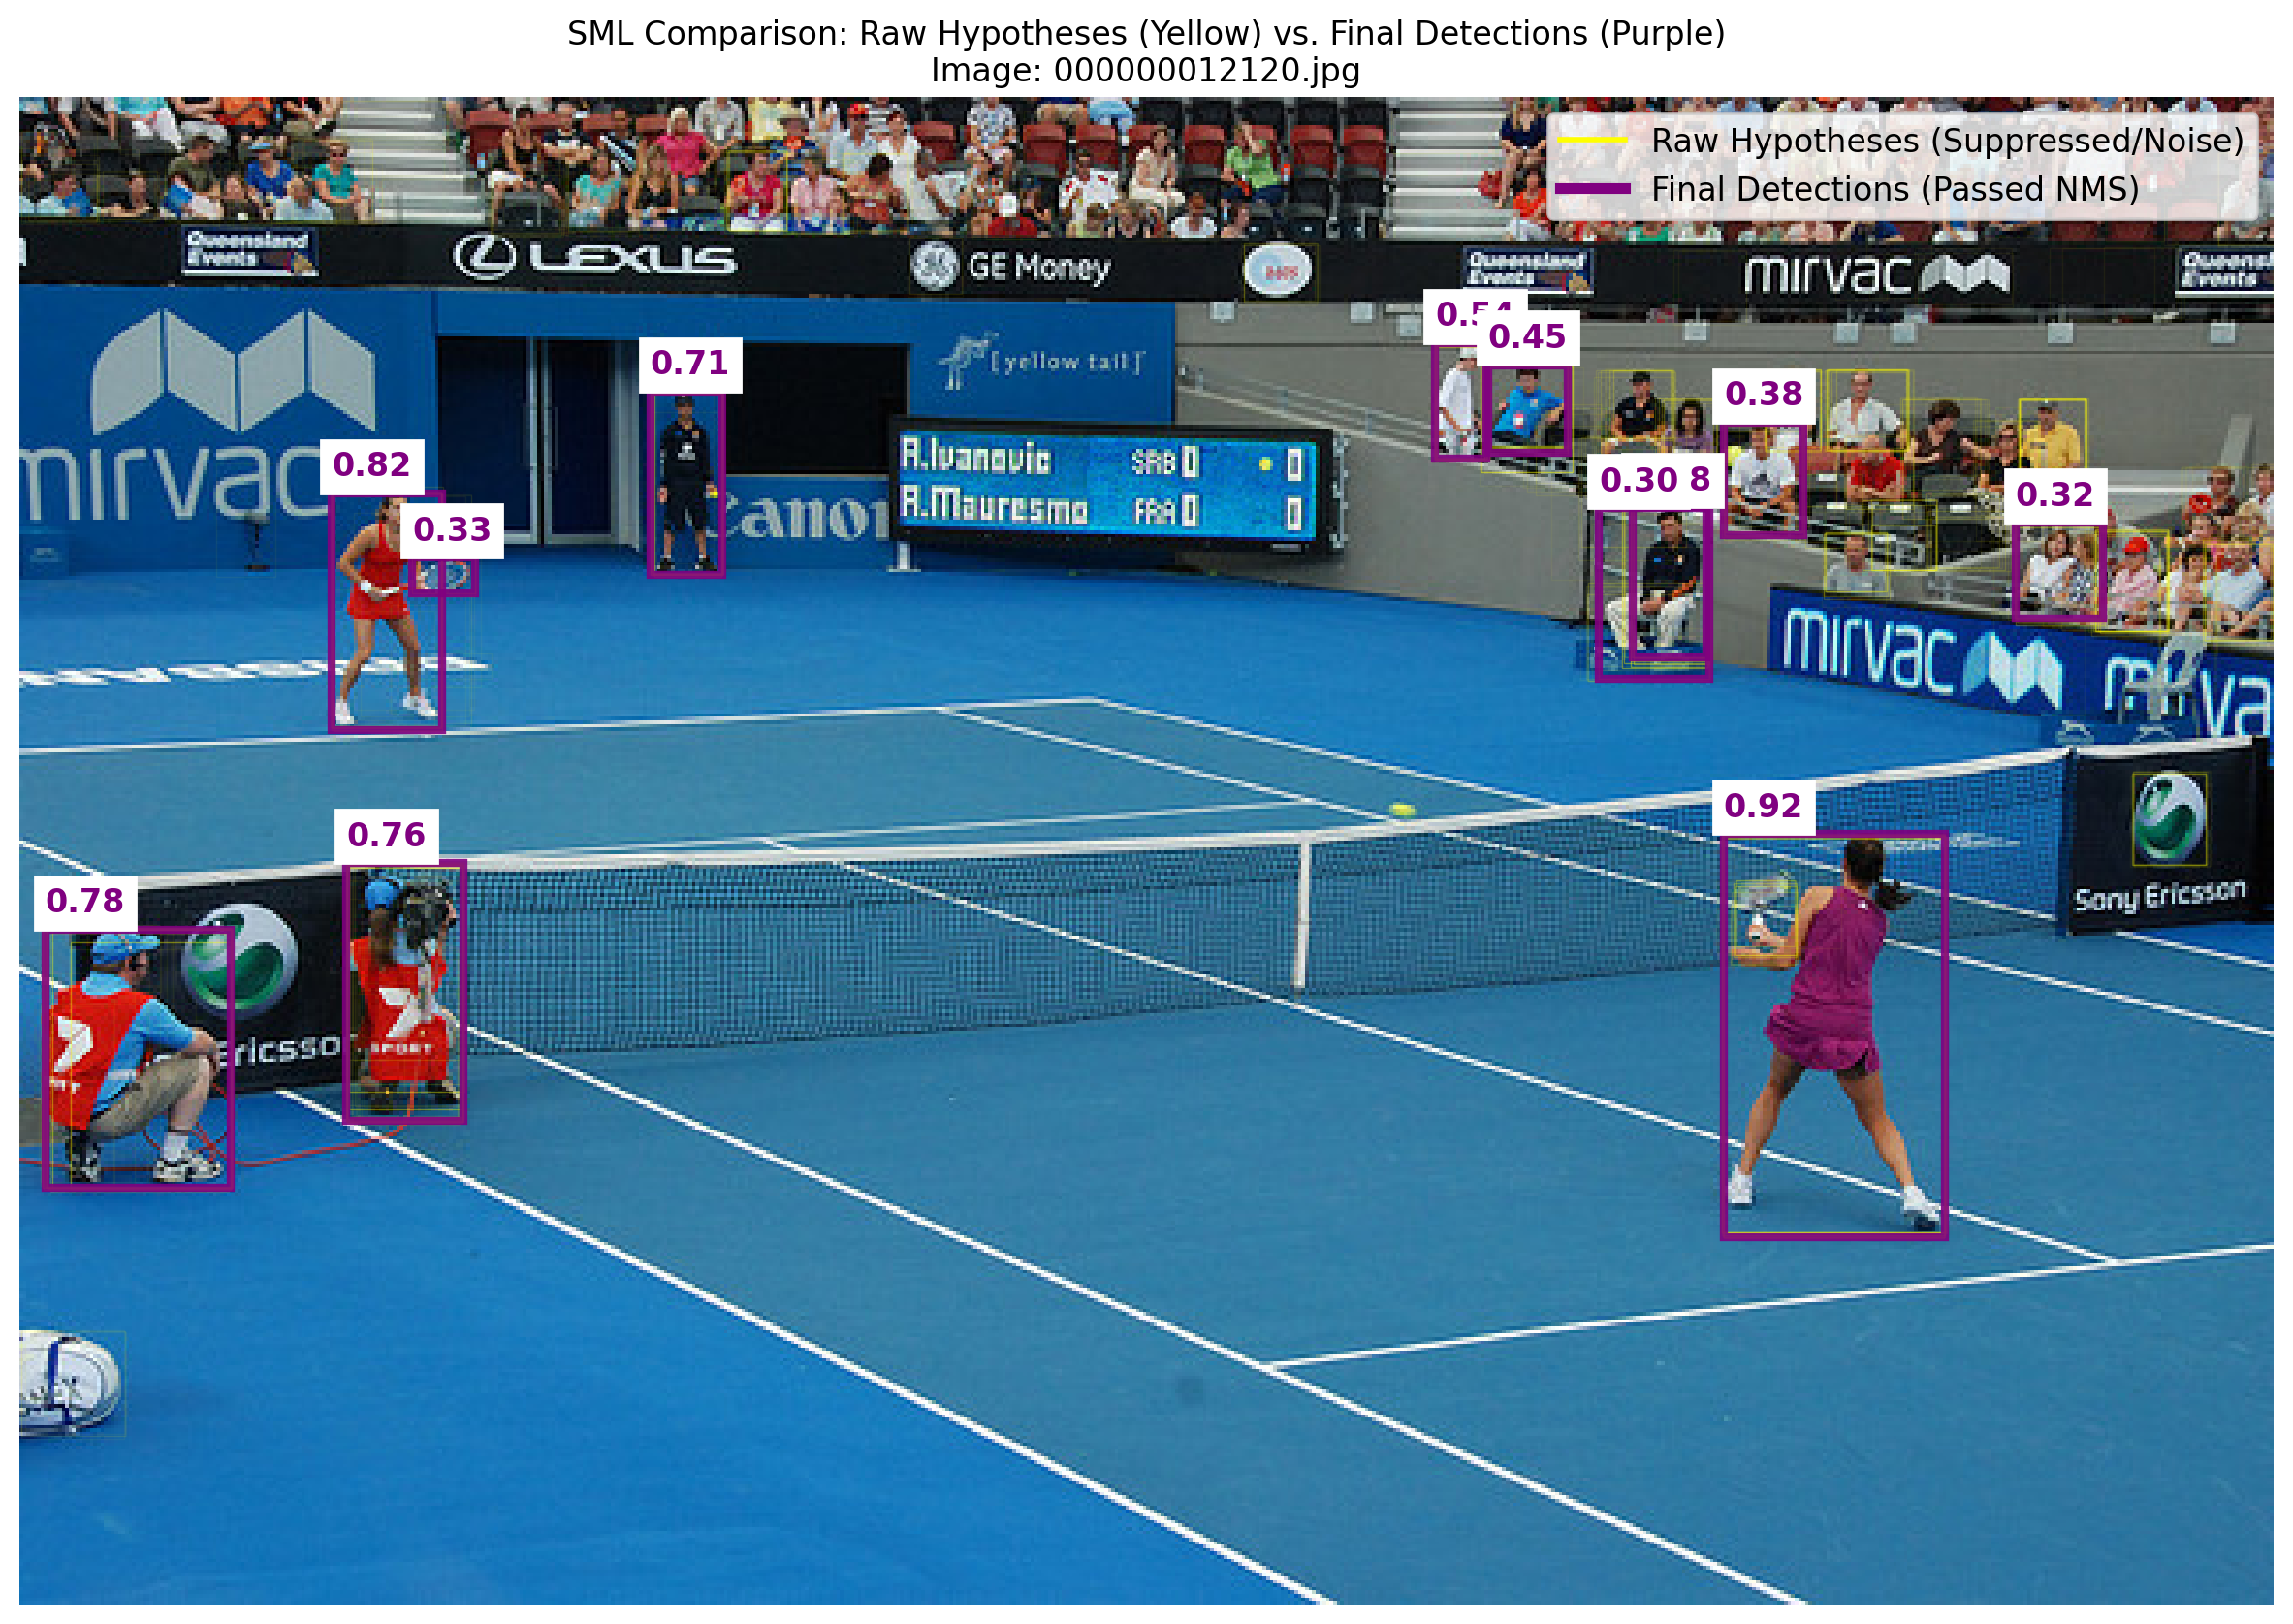

In [151]:
if not os.path.exists("figures/pre_nms_vs_final_comparison_grid.png"):
    %run visualization_scripts/generate_pre_nms_example.py
display(IPImage(filename="figures/pre_nms_vs_final_comparison_grid.png"))


## Figure 3 — Weakest Link distribution

Distribution of correct ($Y_t=0$) and incorrect ($Y_t=1$) inferences for $p_t^{weak}$.


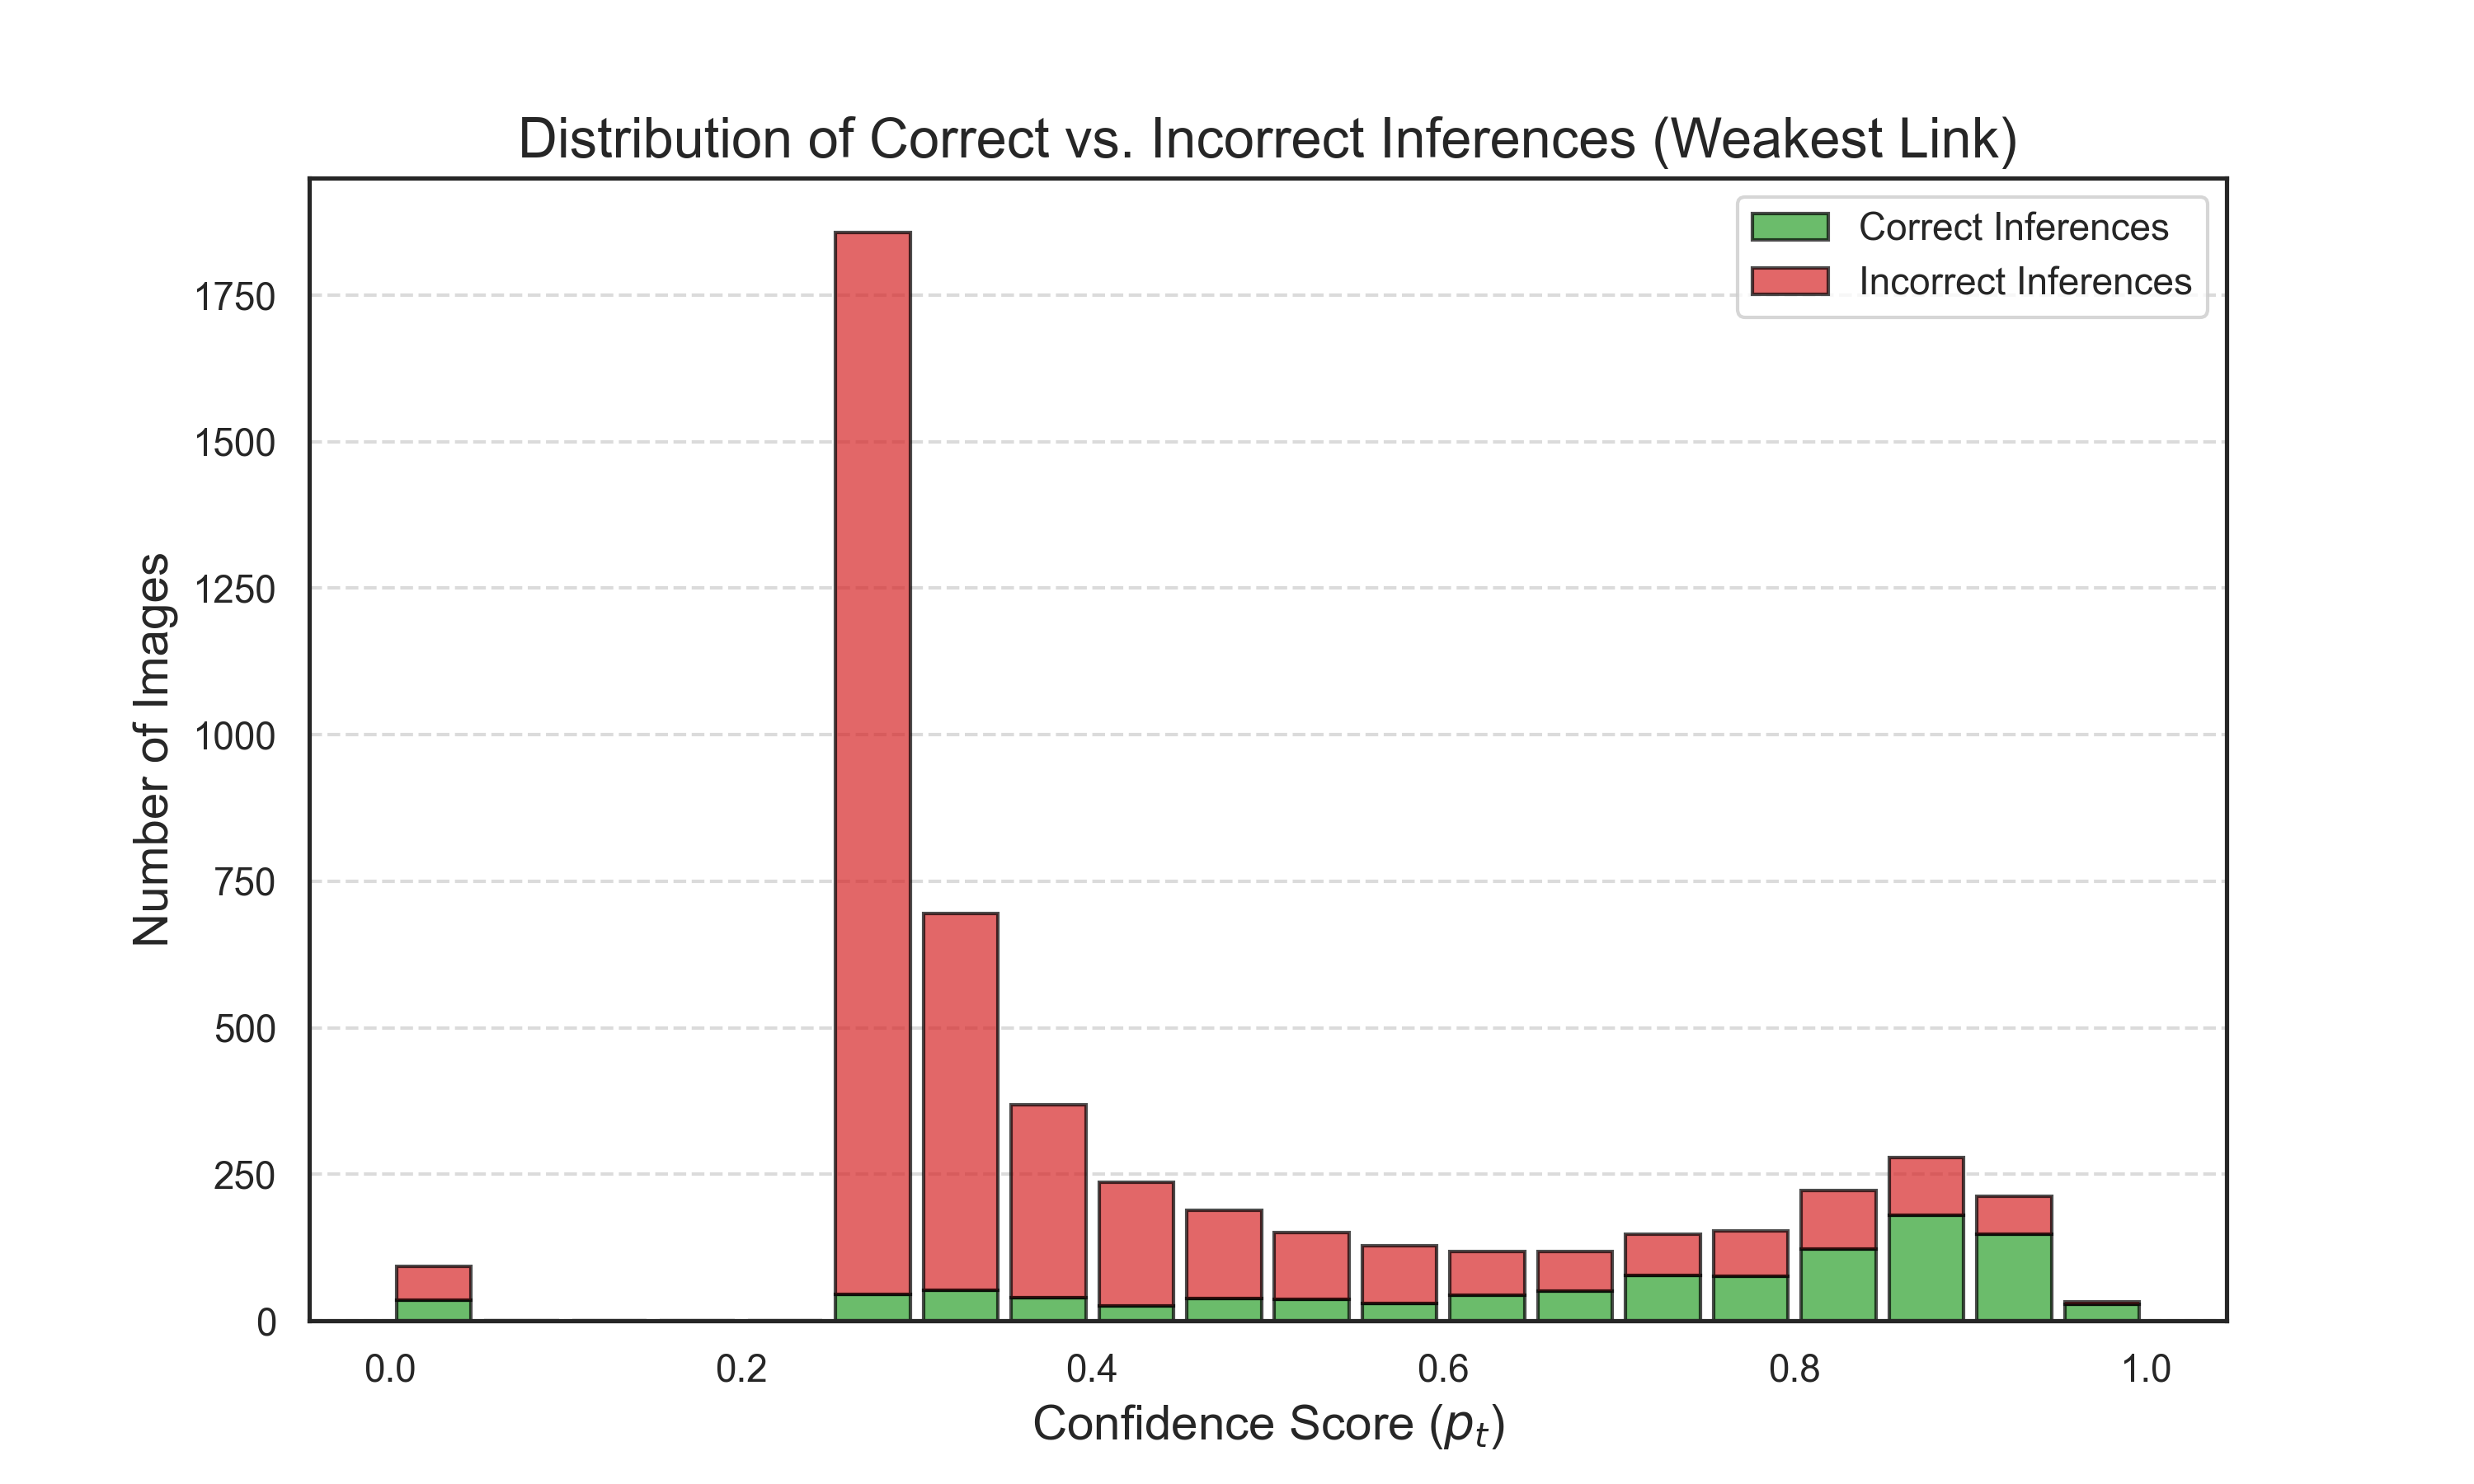

In [152]:
if not os.path.exists("figures/weakest_link_dist.png"):
    %run visualization_scripts/plot_weakest_link_distribution.py
display(IPImage(filename="figures/weakest_link_dist.png"))

## Figure 4 — HIL-F Weakest Link interval weights

Distribution of learned interval weights based on $p_t^{weakest}$.

please run `python visualization_scripts/visualize_weight_evolution.py` to get an interactive visual


## Table 2 — Performance comparison of offloading policies

Every row is calculated from the reference CSVs 

`hilf_results_naive.csv` which corresponds to the result of running hilf with the weakest link metric as our pt

`hilf_results_dual_gate_same_yt.csv` which corresponds to the results of running dual gate hilf with the same cost function for both gates 

`hilf_results_dual_gate_specialized_same_fp_fn.csv` which corresponds to the results of running dual gate hilf with different types of cost functions for both gates

which are obtained from the following simulation scripts

`simulation_scripts/run_hilf_naive.py`

`simulation_scripts/run_hilf_dual_gate_global_cost.py`

`simulation_scripts/run_hilf_dual_gate_specialized_cost.py`

In [154]:
%run analysis_scripts/create_performance_table.py

       Table II: Performance Comparison of Different Offloading Policies        
            Policy Dec. Acc. E2E Acc. Local Acc. Avg. Cost Offload %
       Full Accept     21.7%    21.7%      21.7%     0.783      0.0%
   Coin Flip (50%)     49.1%    59.9%      21.3%     0.646     49.1%
      Full Offload     78.3%   100.0%       0.0%     0.500    100.0%
       Naive HIL-F     82.0%    92.0%      59.3%     0.482     80.4%
               SSM     82.0%    92.1%      59.4%     0.482     80.5%
Dual-Gate (Global)     83.6%    98.8%      84.7%     0.474     92.4%
 Dual-Gate (Spec.)     84.4%    97.3%      76.3%     0.469     88.4%
   Genie Benchmark    100.0%   100.0%     100.0%     0.392     78.3%


## Table 3 — Decision performance of different policies


In [155]:
%run analysis_scripts/create_decision_performance_table.py

             Table III: Decision Performance of Different Policies              
      Policy  Correct Accept  Incorrect Accept  Correct Offload  Incorrect Offload
       Naive             582               399             3517                502
         SSM             579               396             3520                505
 Dual Global             322                58             3858                762
Dual Special             442               137             3779                642


## Table 4 — Failure sources for leaked and caught errors (Naive HIL-F)


In [156]:
%run analysis_scripts/create_failure_mode_table.py

 Table IV: Failure Sources for Leaked and Caught Errors (Naive HIL-F) 
        Failure Mode Incorrect Accepts Correct Offloads
False Negatives (FN)       391 (98.0%)     2930 (83.3%)
False Positives (FP)       391 (98.0%)     3047 (86.6%)
  Misclassifications       328 (82.2%)     2720 (77.3%)
       Total Samples               399             3517


## Tables 5–6 — Dual-Gate (Global) decision performance and correct-offload breakdown


In [157]:
%run analysis_scripts/create_dual_gate_global_tables.py


        Table V (Table 5): Decision Performance for Dual-Gate (Global)        

Rejection Scenario  Correct Accept  Incorrect Accept  Correct Offload  Incorrect Offload
        G_S Reject               0                 0              257                168
        G_W Reject               0                 0              338                257
       Both Reject               0                 0             3263                337
       Both Accept             322                58                0                  0


      Table VI (Table 6): Correct Offloads Breakdown Dual-Gate (Global)       

Rejection Scenario   FN   FP  Misclass.  Total Samples
        G_S Reject  116  211        103            257
        G_W Reject  327  328        288            338
       Both Reject 2825 2845       2623           3263




## Tables 7–8 — Dual-Gate (Specialized) decision performance and correct-offload breakdown


In [158]:
%run analysis_scripts/create_dual_gate_specialized_tables.py


    Table VII (Table 7): Decision Performance for Dual-Gate (Specialized)     

Rejection Scenario  Correct Accept  Incorrect Accept  Correct Offload  Incorrect Offload
        G_S Reject               0                 0              517                248
        G_W Reject               0                 0              318                171
       Both Reject               0                 0             2944                223
       Both Accept             442               137                0                  0


   Table VIII (Table 8): Correct Offloads Breakdown Dual-Gate (Specialized)   

Rejection Scenario   FN   FP  Misclass.  Total Samples
        G_S Reject  261  413        239            517
        G_W Reject  309  312        277            318
       Both Reject 2623 2582       2445           2944




## Provenance and regeneration

- The exact report source is `docs/report-clean/main.tex`.
- Reference data are intentionally not overwritten. New seeded runs use
